In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.io import arff

# Load EEG dataset
data, meta = arff.loadarff(r"C:\Users\BIT\Desktop\BCI GAME\EEG Eye State.arff")
df = pd.DataFrame(data)

# Decode and clean label column
df['eyeDetection'] = df['eyeDetection'].apply(lambda x: int(x.decode('utf-8')))

# Split features and target
y = df['eyeDetection']
X_raw = df.drop(columns=['eyeDetection'])

# Drop constant columns (if any)
constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() == 1]
if constant_cols:
    X_raw.drop(columns=constant_cols, inplace=True)

# Replace NaNs and infs
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.fillna(X_raw.mean(), inplace=True)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# ✅ Summary (clean)
print("✅ Data preprocessing complete.")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_test :", X_test.shape, " | y_test :", y_test.shape)
print()

# ✅ Label distribution in both sets
print("y_train label distribution:\n", pd.Series(y_train).value_counts())
print()
print("y_test label distribution:\n", pd.Series(y_test).value_counts())


✅ Data preprocessing complete.
X_train: (11984, 14)  | y_train: (11984,)
X_test : (2996, 14)  | y_test : (2996,)

y_train label distribution:
 eyeDetection
0    6606
1    5378
Name: count, dtype: int64

y_test label distribution:
 eyeDetection
0    1651
1    1345
Name: count, dtype: int64


***Logistic Regression***

Logistic Regression Performance:
Accuracy : 57.61%
Precision: 54.19%
Recall   : 36.06%
F1 Score : 43.30%

Confusion Matrix (Actual vs Predicted):
[[1241  410]
 [ 860  485]]


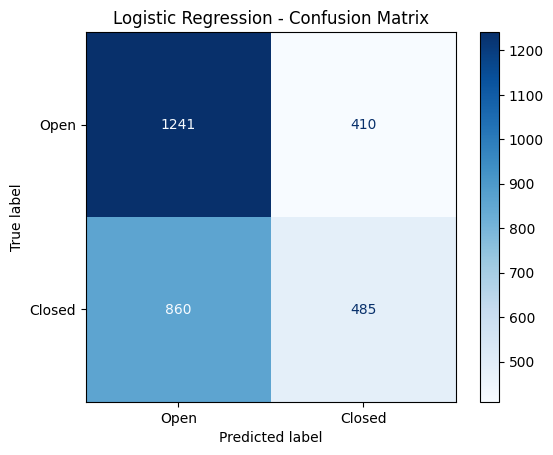

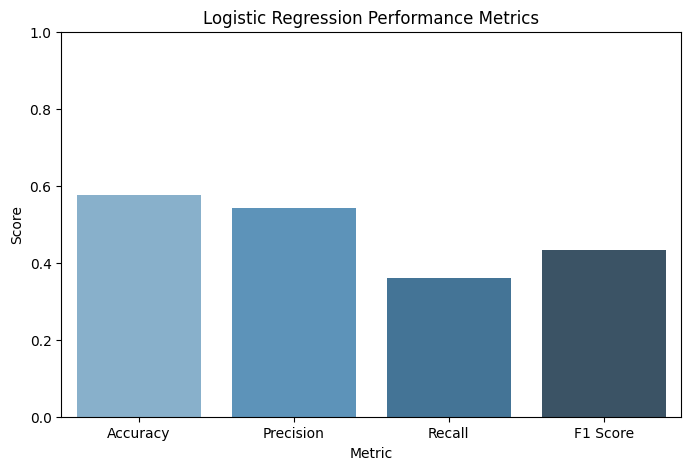

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Train the model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance:")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

# Confusion matrix (text)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Actual vs Predicted):")
print(cm)

# Confusion matrix (plot)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Open', 'Closed'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Bar chart of scores (FutureWarning-safe)
scores = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}
scores_df = pd.DataFrame(scores.items(), columns=["Metric", "Score"])

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=scores_df, palette='Blues_d', legend=False)
plt.ylim(0, 1)
plt.title("Logistic Regression Performance Metrics")
plt.ylabel("Score")
plt.show()


Logistic Regression (Balanced Class Weights) Performance:
Accuracy : 55.51%
Precision: 50.40%
Recall   : 56.88%
F1 Score : 53.44%

Confusion Matrix (Actual vs Predicted):
[[898 753]
 [580 765]]


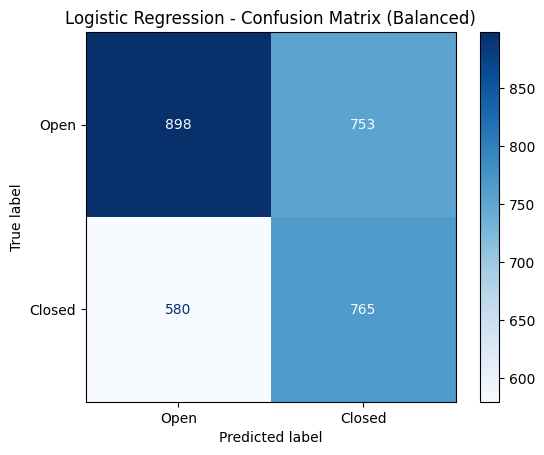

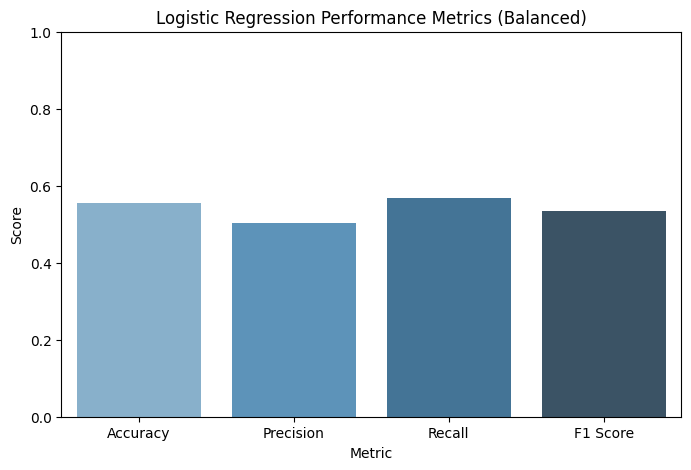

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Train the model with class_weight='balanced'
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Predict
y_pred = log_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display metrics
print("Logistic Regression (Balanced Class Weights) Performance:")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# ✅ Print confusion matrix (text)
print("\nConfusion Matrix (Actual vs Predicted):")
print(cm)

# ✅ Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Open', 'Closed'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Logistic Regression - Confusion Matrix (Balanced)")
plt.show()

# Bar chart of metrics
scores = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
}
scores_df = pd.DataFrame(scores.items(), columns=["Metric", "Score"])

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=scores_df, palette='Blues_d', legend=False)
plt.ylim(0, 1)
plt.title("Logistic Regression Performance Metrics (Balanced)")
plt.ylabel("Score")
plt.show()


***SVM***

SVM Performance:
Accuracy : 65.29%
Precision: 60.03%
Recall   : 67.88%
F1 Score : 63.71%

Confusion Matrix (Actual vs Predicted):
[[1043  608]
 [ 432  913]]


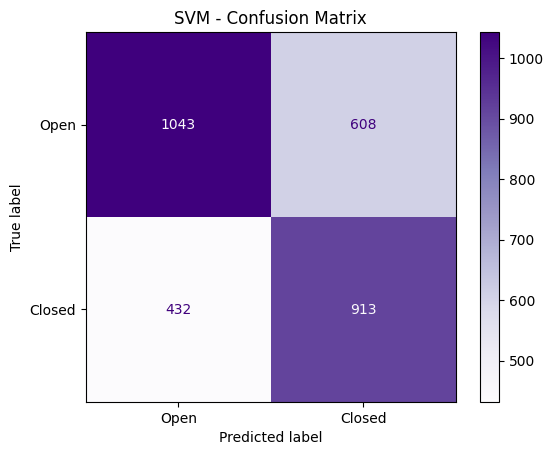

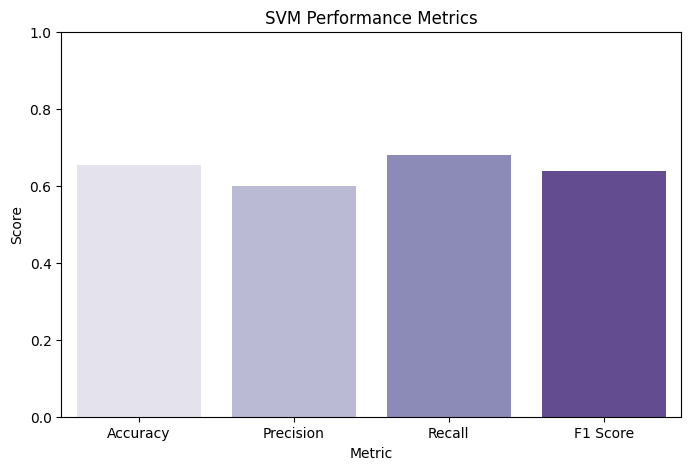

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train the SVM model (RBF kernel)
svm_model = SVC(kernel='rbf',class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# ✅ 1. Print metrics
print("SVM Performance:")
print(f"Accuracy : {accuracy_svm*100:.2f}%")
print(f"Precision: {precision_svm*100:.2f}%")
print(f"Recall   : {recall_svm*100:.2f}%")
print(f"F1 Score : {f1_svm*100:.2f}%")

# ✅ 2. Print confusion matrix (text)
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix (Actual vs Predicted):")
print(cm_svm)

# ✅ 3. Plot confusion matrix
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Open', 'Closed'])
disp_svm.plot(cmap="Purples", values_format='d')
plt.title("SVM - Confusion Matrix")
plt.show()

# ✅ 4. Bar chart of metrics
svm_scores = {
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1 Score': f1_svm
}
svm_scores_df = pd.DataFrame(svm_scores.items(), columns=["Metric", "Score"])

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=svm_scores_df, palette='Purples', legend=False)
plt.ylim(0, 1)
plt.title("SVM Performance Metrics")
plt.ylabel("Score")
plt.show()


***Random Forest***

Random Forest Performance:
Accuracy : 93.06%
Precision: 94.52%
Recall   : 89.74%
F1 Score : 92.07%

Confusion Matrix (Actual vs Predicted):
[[1581   70]
 [ 138 1207]]


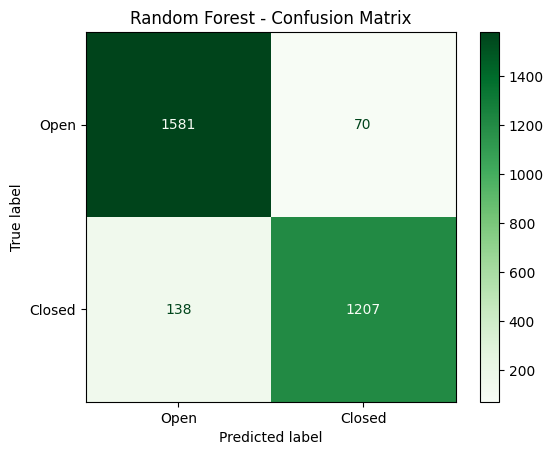

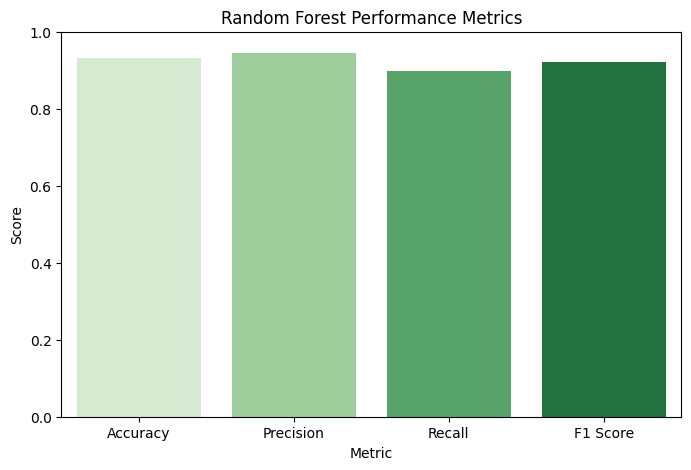

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# ✅ 1. Print metrics
print("Random Forest Performance:")
print(f"Accuracy : {accuracy_rf*100:.2f}%")
print(f"Precision: {precision_rf*100:.2f}%")
print(f"Recall   : {recall_rf*100:.2f}%")
print(f"F1 Score : {f1_rf*100:.2f}%")

# ✅ 2. Print confusion matrix (text)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Actual vs Predicted):")
print(cm_rf)

# ✅ 3. Plot confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Open', 'Closed'])
disp_rf.plot(cmap="Greens", values_format='d')
plt.title("Random Forest - Confusion Matrix")
plt.show()

# ✅ 4. Bar chart of metrics
rf_scores = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf
}
rf_scores_df = pd.DataFrame(rf_scores.items(), columns=["Metric", "Score"])

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=rf_scores_df, palette='Greens', legend=False)
plt.ylim(0, 1)
plt.title("Random Forest Performance Metrics")
plt.ylabel("Score")
plt.show()


In [9]:
y_test_array = y_test.to_numpy()

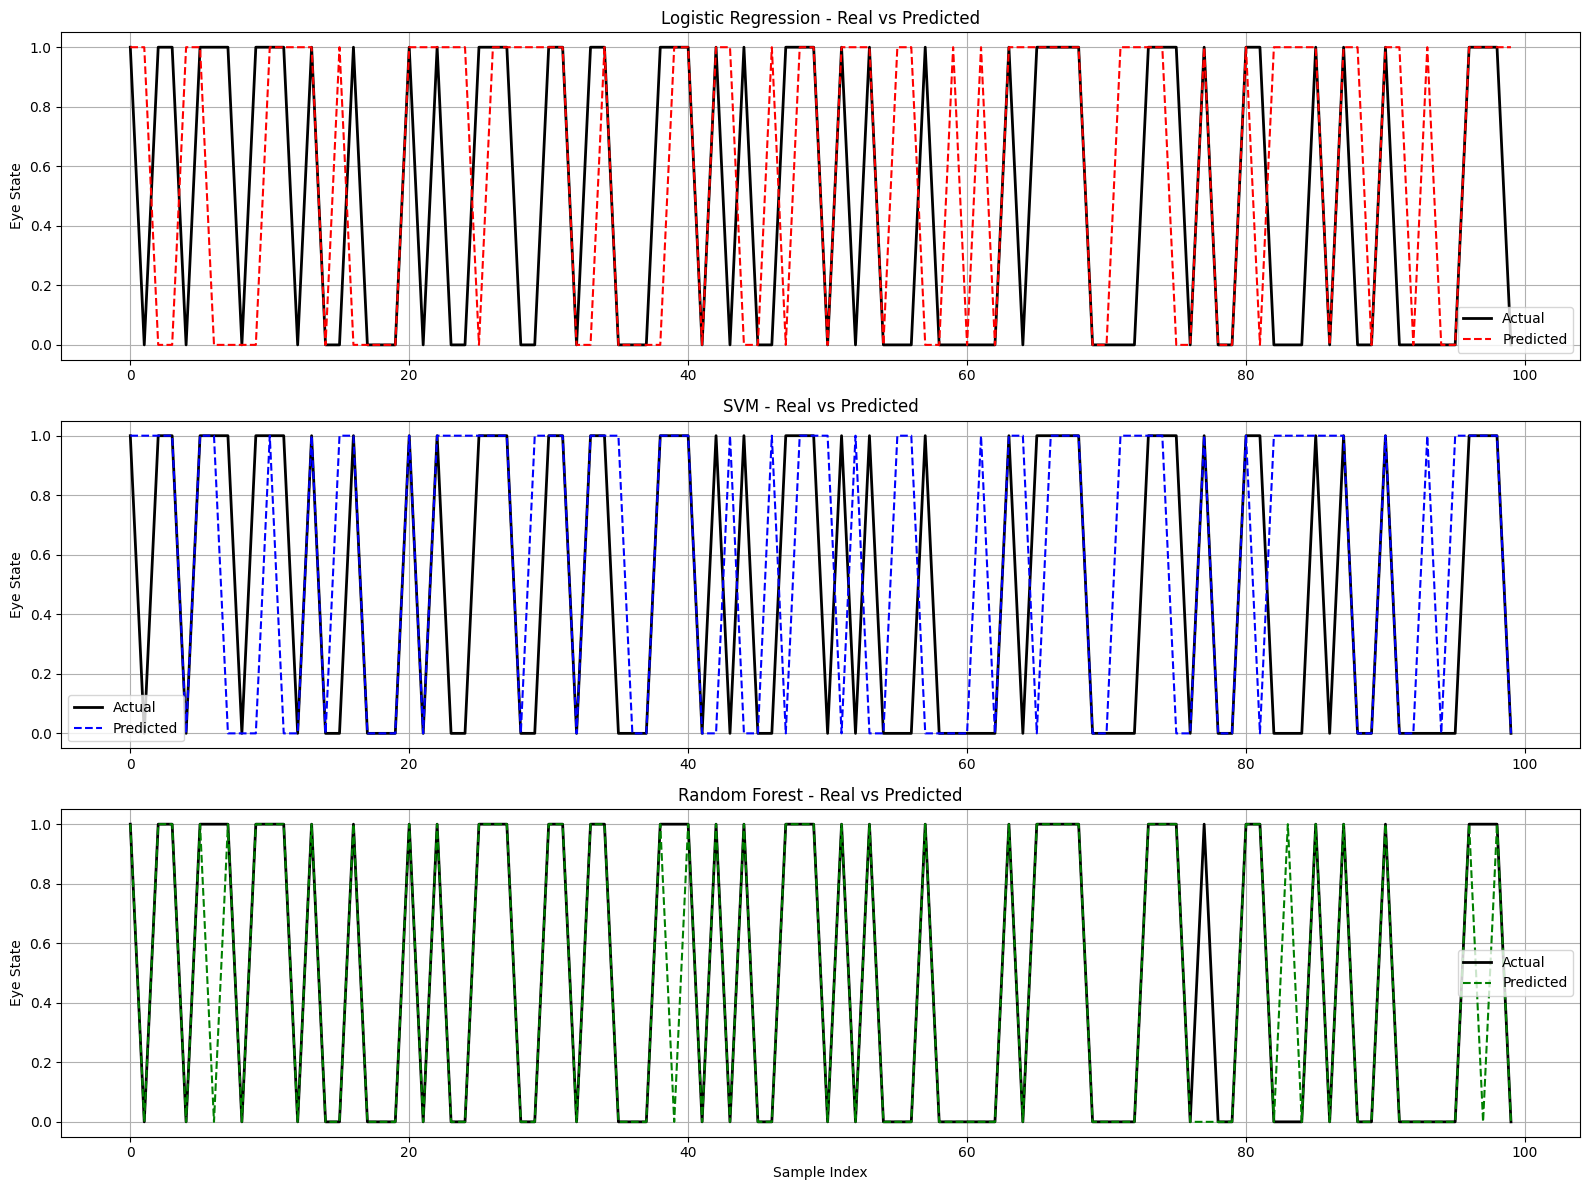

In [10]:
import matplotlib.pyplot as plt

# Plot for first N samples
N = 100

plt.figure(figsize=(16, 12))

# Subplot 1: Logistic Regression
plt.subplot(3, 1, 1)
plt.plot(range(N), y_test_array[:N], label='Actual', color='black', linewidth=2)
plt.plot(range(N), log_pred[:N], label='Predicted', color='red', linestyle='--')
plt.title("Logistic Regression - Real vs Predicted")
plt.ylabel("Eye State")
plt.grid(True)
plt.legend()

# Subplot 2: SVM
plt.subplot(3, 1, 2)
plt.plot(range(N), y_test_array[:N], label='Actual', color='black', linewidth=2)
plt.plot(range(N), svm_pred[:N], label='Predicted', color='blue', linestyle='--')
plt.title("SVM - Real vs Predicted")
plt.ylabel("Eye State")
plt.grid(True)
plt.legend()

# Subplot 3: Random Forest
plt.subplot(3, 1, 3)
plt.plot(range(N), y_test_array[:N], label='Actual', color='black', linewidth=2)
plt.plot(range(N), rf_pred[:N], label='Predicted', color='green', linestyle='--')
plt.title("Random Forest - Real vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Eye State")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
